In [1]:
# plot_preference_distance_matrices.py

import numpy as np
from utilityFunctions import (
    load_csv_to_matrix_batch,
    compute_color_preference_distance_batch,
    show_heatmaps,
)

Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.csv
raw_data/202411_data/subject_04_609c10.csv
raw_data/202411_data/subject_05_60d129.csv
raw_data/202411_data/subject_06_610814.csv
raw_data/202411_data/subject_07_6171f3.csv
raw_data/202411_data/subject_08_65a3ab.csv
raw_data/202411_data/subject_09_65f13c.csv
raw_data/202411_data/subject_10_65f18d.csv
raw_data/202411_data/subject_11_65fa3b.csv
raw_data/202411_data/subject_12_663180.csv
raw_data/202411_data/subject_13_667c6c.csv
raw_data/202411_data/subject_14_667df4.csv
raw_data/202411_data/subject_15_668110.csv
raw_data/202411_data/subject_16_6681ad.csv
raw_data/202411_data/subject_17_66906a.csv
raw_data/202411_data/subject_18_66a502.csv
raw_data/202411_data/subject_19_6734b5.csv
Loaded 19 raw preference matrices.


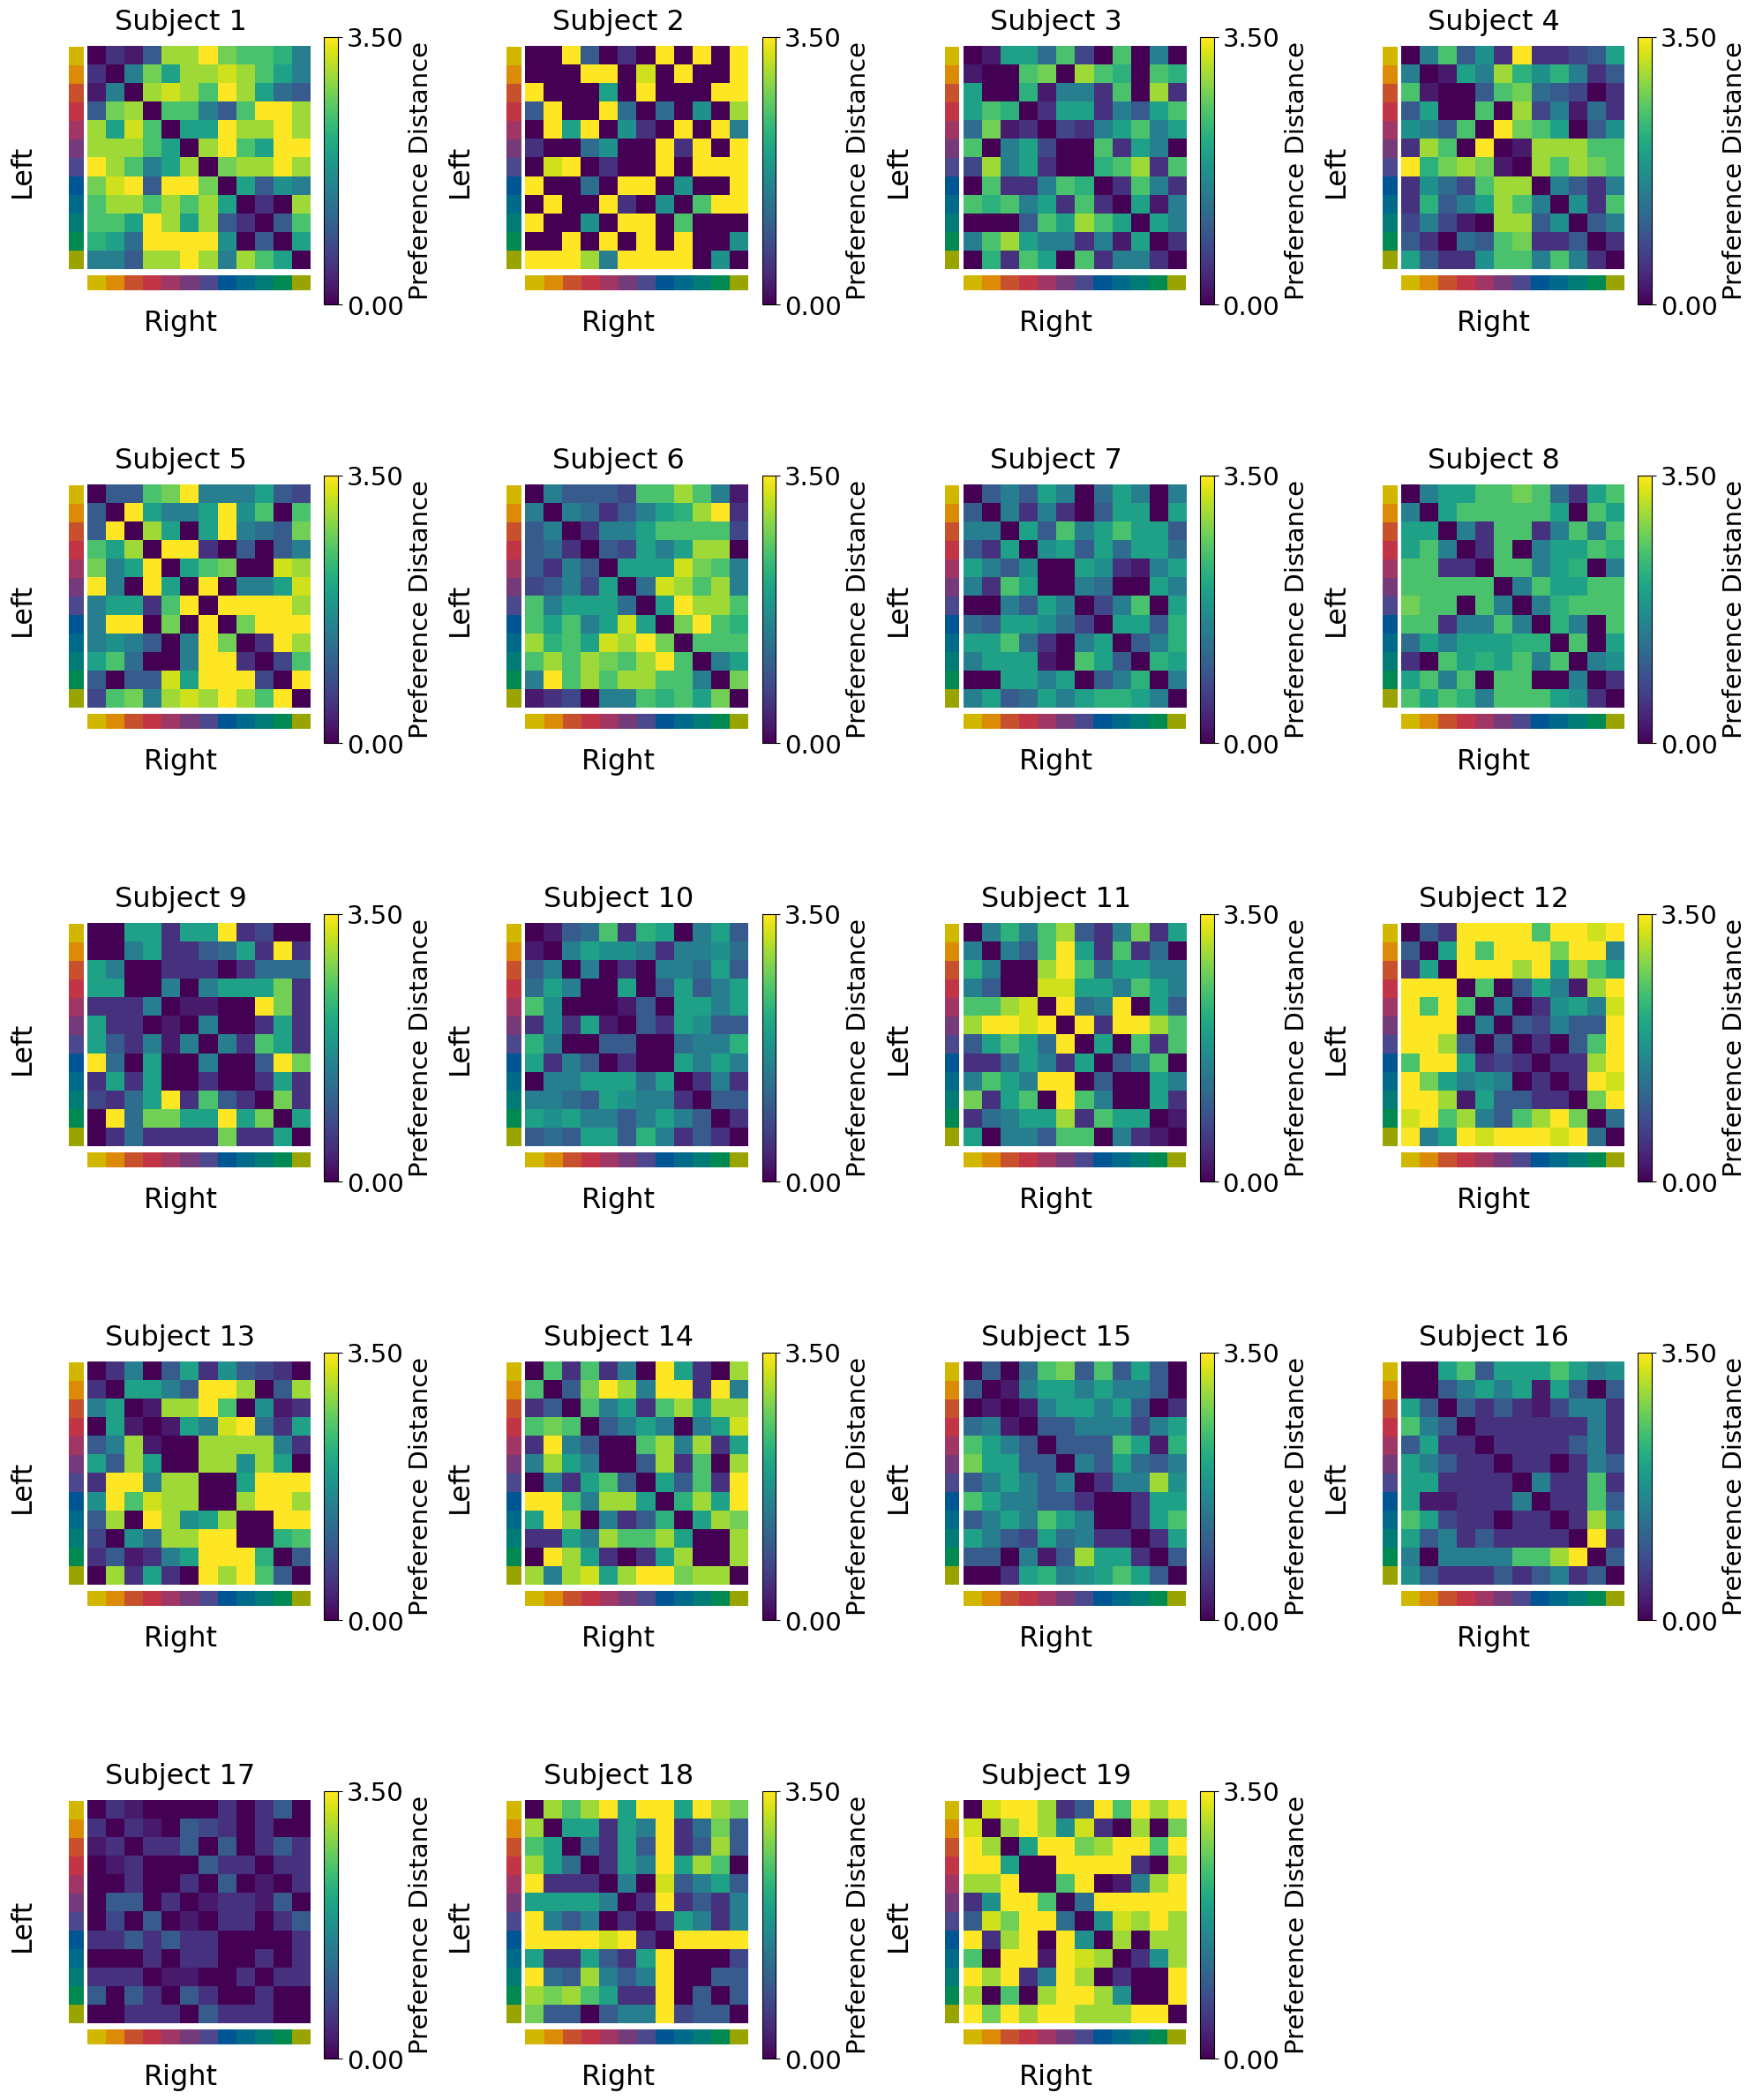

In [3]:

# -------------------------
# Config (adjust as needed)
# -------------------------
folder_path = "raw_data/202411_data"   # path to your CSVs
response_type = "preference"

unique_colours = np.array([
    '#d2b700', '#db8b08', '#c7512c', '#c13547', '#a03663', '#753a7a',
    '#4b488e', '#005692', '#006a8b', '#007b75', '#008a52', '#9aa400'
])
colour_index = {c: i for i, c in enumerate(unique_colours)}
matrix_size = len(unique_colours)

# -------------------------
# Load raw preference matrices
# -------------------------
subject_matrices_preference_raw = load_csv_to_matrix_batch(
    folder_path=folder_path,
    response_type=response_type,
    colour_index=colour_index,
    matrix_size=matrix_size
)
n_subjects = len(subject_matrices_preference_raw)
print(f"Loaded {n_subjects} raw preference matrices.")

# -------------------------
# Convert to preference distance matrices
# (|antisymmetrised| as defined in your new function)
# -------------------------
subject_matrices_preference_distance = compute_color_preference_distance_batch(
    subject_matrices_preference_raw
)

# -------------------------
# Plot all subjects in one figure
# -------------------------
# Global vmin/vmax for consistent color scaling
vmin_val = 0.0
vmax_val = 3.5

# A simple 5x4 grid works well for 19 subjects; adjust if you have a different N
nrows = 5
ncols = 4
titles = [f"Subject {i+1}" for i in range(n_subjects)]

show_heatmaps(
    vmin_val=vmin_val,
    vmax_val=vmax_val,
    matrices=subject_matrices_preference_distance,
    titles=titles,
    nrows=nrows,
    ncols=ncols,
    cmap_name="viridis",
    cbar_label="Preference Distance",
    color_labels=unique_colours,  # pass None if your show_heatmaps expects no color labels here
)
